# Transcript Embedding Analysis — 4 approaches across all debates

**Data:** 843 debate speech segments (Whisper) across 28 debates, 8 candidates.
Each segment has a 4096-d EuroLLM text embedding encoding *what was said*.

**Four questions:**
- **A. Topic distribution** — what topics does each candidate talk about?
- **B. Cosine similarity** — which candidates talk about similar things?
- **C. Message discipline** — how consistent is each candidate across debates?
- **D. Semantic drift** — does a candidate's agenda shift over the campaign timeline?

## Setup

In [ ]:
import sys, os
# works whether Jupyter is started from project root or from a subfolder
sys.path.insert(0, 'multivideo_analysis')
sys.path.insert(0, '../multivideo_analysis')
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from datetime import date

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
FEATURES_DIR = '../Project_Features'

CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura'
]

# Consistent color per candidate (roughly left → right)
CAND_COLOR = {
    'Martins':            '#e41a1c',
    'Filipe':             '#984ea3',
    'Pinto':              '#ff7f00',
    'Seguro':             '#377eb8',
    'Gouveia_Melo':       '#4daf4a',
    'Cotrim_Figueiredo':  '#a65628',
    'Marques_Mendes':     '#f781bf',
    'Ventura':            '#222222',
}

### Load audio data + assign speaker labels

In [6]:
# Load all audio pkls
audio_files = sorted([f for f in os.listdir(FEATURES_DIR) if f.endswith('_audio.pkl')])
dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_audio.pkl', '')
    dfs.append(df)
data = pd.concat(dfs, ignore_index=True)

def parse_embedding(s):
    return s if isinstance(s, np.ndarray) else np.fromstring(s.strip('[]'), sep=' ')
data['speak_embeddings'] = data['speak_embeddings'].apply(parse_embedding)

data_parties = pd.read_pickle(os.path.join(FEATURES_DIR, 'candidate_party.pkl'))
candidate_to_party = dict(zip(data_parties['Candidate'], data_parties['Party']))

def extract_candidates(video_name):
    for c in CANDIDATES:
        if video_name.startswith(c):
            rest = video_name[len(c) + len('_vs_'):]
            for c2 in CANDIDATES:
                if rest.startswith(c2):
                    return c, c2
    return None, None

debate_videos = sorted(v for v in data['video'].unique() if 'vs' in v)
print(f'{len(data)} audio segments | {len(debate_videos)} debate videos')

2656 audio segments | 28 debate videos


In [7]:
# k=3 clustering per debate
debate_centroids = {}
cluster_col = np.full(len(data), -1, dtype=int)
for v in debate_videos:
    idx = data.index[data['video'] == v]
    E = np.stack(data.loc[idx, 'speak_embeddings'].values)
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_col[idx] = km.fit_predict(E)
    debate_centroids[v] = km.cluster_centers_
data['cluster_k3'] = cluster_col

# Cross-debate centroid anchoring → global centroid per candidate
def find_candidate_centroid_per_debate(candidate, dc):
    their = [v for v in dc if candidate in v]
    if len(their) < 2: return {}
    best = {}
    for video in their:
        others = [v for v in their if v != video]
        cen = dc[video]
        scores = []
        for ci in range(3):
            scores.append(sum(cdist(cen[ci:ci+1], dc[ov], metric='cosine')[0].min()
                             for ov in others))
        best[video] = cen[int(np.argmin(scores))]
    return best

cand_debate_cen = {c: find_candidate_centroid_per_debate(c, debate_centroids) for c in CANDIDATES}
global_centroids = {c: np.mean(np.stack(list(cand_debate_cen[c].values())), axis=0)
                    for c in CANDIDATES if cand_debate_cen[c]}

# Assign speaker labels
speaker_col = np.full(len(data), 'unknown', dtype=object)
for v in debate_videos:
    cA, cB = extract_candidates(v)
    if cA is None: continue
    idx = data.index[data['video'] == v]
    cen = debate_centroids[v]
    dA = cdist(cen, global_centroids[cA].reshape(1,-1), metric='cosine').flatten()
    dB = cdist(cen, global_centroids[cB].reshape(1,-1), metric='cosine').flatten()
    avail = {0, 1, 2}
    c2s = {}
    bA = int(np.argmin([dA[i] if i in avail else np.inf for i in range(3)]))
    c2s[bA] = cA; avail.remove(bA)
    bB = int(np.argmin([dB[i] if i in avail else np.inf for i in range(3)]))
    c2s[bB] = cB; avail.remove(bB)
    c2s[avail.pop()] = 'host'
    speaker_col[idx] = [c2s[l] for l in data.loc[idx, 'cluster_k3'].values]

data['speaker'] = speaker_col
data['party']   = data['speaker'].map(candidate_to_party).fillna('host')
print('Speaker distribution:')
print(data[data['video'].isin(debate_videos)]['speaker'].value_counts())

Speaker distribution:
speaker
host                 549
Marques_Mendes       336
Gouveia_Melo         330
Seguro               293
Cotrim_Figueiredo    281
Martins              260
Filipe               242
Ventura              195
Pinto                170
Name: count, dtype: int64


### Load speech transcripts and join speaker labels

In [8]:
# Load all debate speech pkls (exclude Telejornal)
speech_files = sorted(f for f in os.listdir(FEATURES_DIR)
                      if f.endswith('_speech.pkl') and 'Telejornal' not in f)
sdfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_speech.pkl', '')
    sdfs.append(df)
speech_all = pd.concat(sdfs, ignore_index=True).reset_index(drop=True)

def parse_text_emb(x):
    return x if isinstance(x, np.ndarray) else np.array(x)
speech_all['text_embedding'] = speech_all['text_embedding'].apply(parse_text_emb)

print(f'{len(speech_all)} speech segments across {speech_all["video"].nunique()} debate videos')
print('Columns:', list(speech_all.columns))

843 speech segments across 28 debate videos
Columns: ['timestamp', 'duration', 'transcript', 'text_embedding', 'video']


In [9]:
# Join speaker labels to speech segments via time overlap.
# Each speech segment [timestamp, timestamp+duration) is matched to the
# audio-labeled speaker whose segments overlap with it the most.

audio_lab = data[data['speaker'].isin(CANDIDATES)].copy()
audio_lab['a_end'] = audio_lab['time stamp'] + audio_lab['duration']

def dominant_speaker(video, ts, dur):
    te = ts + dur
    ov = audio_lab[(audio_lab['video'] == video) &
                   (audio_lab['time stamp'] < te) &
                   (audio_lab['a_end'] > ts)].copy()
    if ov.empty: return 'unknown'
    ov['overlap'] = ov.apply(lambda r: min(r['a_end'], te) - max(r['time stamp'], ts), axis=1)
    return ov.groupby('speaker')['overlap'].sum().idxmax()

speech_all['speaker'] = speech_all.apply(
    lambda r: dominant_speaker(r['video'], float(r['timestamp']), float(r['duration'])), axis=1)
speech_all['party'] = speech_all['speaker'].map(candidate_to_party)

# Keep only candidate-labeled segments for analysis
speech_cands = speech_all[speech_all['speaker'].isin(CANDIDATES)].copy().reset_index(drop=True)
print(f'Candidate-labeled speech segments: {len(speech_cands)}')
print(speech_cands['speaker'].value_counts())

Candidate-labeled speech segments: 773
speaker
Marques_Mendes       119
Pinto                116
Martins              106
Ventura              104
Filipe               102
Seguro               101
Cotrim_Figueiredo     98
Gouveia_Melo          27
Name: count, dtype: int64


---
## Option A — Topic distribution per candidate

**Approach:** cluster all candidate speech segments in text-embedding space into K topics,
label each cluster with its top TF-IDF terms, then build a per-candidate topic histogram.

Comparing candidates in topic-distribution space is statistically sound (chi-square test)
and immediately interpretable — unlike comparing raw embedding centroids.

Variance explained by 50 PCs: 76.0%


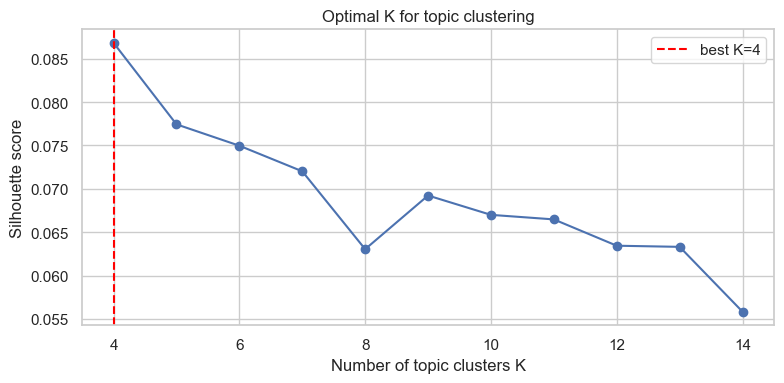

Best K: 4


In [10]:
# Reduce 4096-d text embeddings to 50 PCs before clustering
# (speeds up KMeans dramatically; PCA preserves most semantic variance)
X = np.stack(speech_cands['text_embedding'].values)
pca_pre = PCA(n_components=50, random_state=42)
X50 = pca_pre.fit_transform(X)
print(f'Variance explained by 50 PCs: {pca_pre.explained_variance_ratio_.sum():.1%}')

# Find optimal K via silhouette score (K = 4 … 14)
sil = []
K_range = range(4, 15)
for k in K_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X50)
    sil.append(silhouette_score(X50, labels, sample_size=min(500, len(X50))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), sil, marker='o')
ax.set_xlabel('Number of topic clusters K')
ax.set_ylabel('Silhouette score')
ax.set_title('Optimal K for topic clustering')
best_K = list(K_range)[int(np.argmax(sil))]
ax.axvline(best_K, color='red', ls='--', label=f'best K={best_K}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best K: {best_K}')

In [11]:
# Fit final KMeans with best_K
km_topics = KMeans(n_clusters=best_K, random_state=42, n_init=20)
speech_cands = speech_cands.copy()
speech_cands['topic'] = km_topics.fit_predict(X50)

# Label each cluster with top TF-IDF terms from the transcripts it contains
PT_STOP = {
    'de','a','o','que','e','do','da','em','um','para','com','uma','os','no','se',
    'na','por','mais','as','dos','como','mas','ao','ele','das','tem','seu','sua',
    'ou','ser','quando','muito','nos','ja','eu','so','pelo','pela','ate','isso',
    'ela','entre','era','depois','sem','mesmo','aos','ter','seus','suas','numa',
    'nem','nas','esse','nao','num','ha','sobre','este','foi','pelos','pelas',
    'essa','esses','essas','isto','aqui','la','cada','qual','todo','toda','todos',
    'todas','outro','outra','outros','outras','ainda','pois','porque','assim',
    'lhe','temos','pode','podem','vai','sao','esta','tenho','diz','bem','pouco',
    'onde','menos','desde','antes','depois','contra','diante','conforme','segundo',
    'exceto','salvo','aquele','aquela','neste','nessa','naquele','vamos','vemos',
    'disse','disser','tambem','aquilo','ali','tudo','nada','sempre','nunca',
    'agora','entao','porem','contudo','todavia','portanto','logo','pois',
    'nem','quer','seja','caso','apos','durante','perante','mediante','junto'
}

def clean(t):
    t = str(t).lower()
    t = re.sub(r'[^\w\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

speech_cands['clean_text'] = speech_cands['transcript'].apply(clean)

tfidf = TfidfVectorizer(max_features=8000, min_df=2, stop_words=list(PT_STOP))
X_tfidf = tfidf.fit_transform(speech_cands['clean_text'])
terms = np.array(tfidf.get_feature_names_out())

topic_labels = {}
for k in range(best_K):
    mask = speech_cands['topic'] == k
    if mask.sum() == 0:
        topic_labels[k] = f'T{k}'
        continue
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top5 = terms[mean_tfidf.argsort()[-5:][::-1]]
    topic_labels[k] = f'T{k}: ' + ', '.join(top5)
    print(f'Topic {k:2d} ({mask.sum():3d} segs): {topic_labels[k]}')

speech_cands['topic_label'] = speech_cands['topic'].map(topic_labels)

Topic  0 (185 segs): T0: não, nós, há, república, são
Topic  1 (180 segs): T1: não, estado, nós, me, está
Topic  2 (201 segs): T2: não, dizer, senhor, está, só
Topic  3 (207 segs): T3: não, nós, república, país, acho


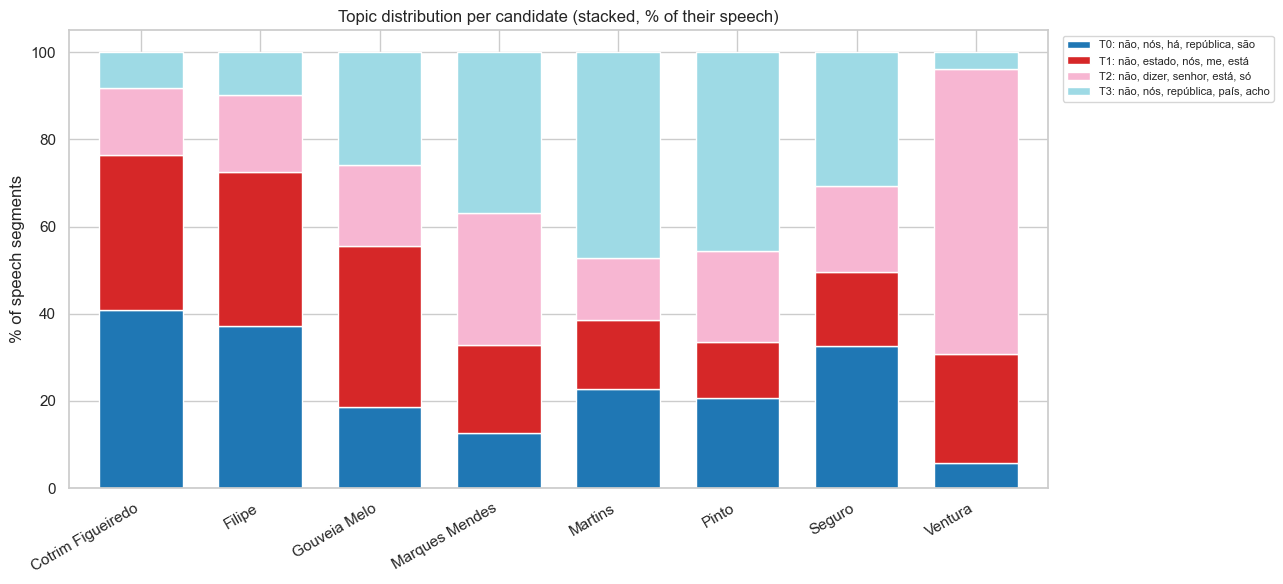

In [12]:
# Per-candidate topic distribution — stacked bar chart
pivot = (speech_cands.groupby(['speaker', 'topic_label'])
         .size().unstack(fill_value=0))
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.loc[CANDIDATES]  # consistent row order

fig, ax = plt.subplots(figsize=(13, 6))
pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.7)
ax.set_xlabel('')
ax.set_ylabel('% of speech segments')
ax.set_title('Topic distribution per candidate (stacked, % of their speech)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xticklabels([c.replace('_', ' ') for c in pivot_pct.index], rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# Chi-square test of independence: are topic distributions different across candidates?
contingency = (speech_cands[speech_cands['speaker'].isin(CANDIDATES)]
               .groupby(['speaker', 'topic']).size().unstack(fill_value=0))
contingency = contingency.loc[CANDIDATES]

chi2, p, dof, expected = chi2_contingency(contingency.values)
print(f'Chi-square test (candidate × topic)')
print(f'  chi2 = {chi2:.1f},  dof = {dof},  p = {p:.2e}')
if p < 0.05:
    print('  -> Topic distributions differ significantly across candidates (p < 0.05)')
else:
    print('  -> No significant difference in topic distributions (p >= 0.05)')

# Which candidate dominates each topic?
print()
print('Dominant candidate per topic:')
for t in range(best_K):
    col = contingency[t] if t in contingency.columns else pd.Series(dtype=float)
    if col.sum() > 0:
        dom = col.idxmax()
        share = 100 * col[dom] / col.sum()
        print(f'  T{t:2d}: {dom} ({share:.0f}% of segs in this topic)')

Chi-square test (candidate × topic)
  chi2 = 229.5,  dof = 21,  p = 5.25e-37
  -> Topic distributions differ significantly across candidates (p < 0.05)

Dominant candidate per topic:
  T 0: Cotrim_Figueiredo (22% of segs in this topic)
  T 1: Filipe (20% of segs in this topic)
  T 2: Ventura (34% of segs in this topic)
  T 3: Pinto (26% of segs in this topic)


---
## Option B — Pairwise cosine similarity between candidates

Compute each candidate's centroid in the original 4096-d text-embedding space,
then measure cosine similarity between all pairs.
This is the correct metric for embeddings (unlike Pearson correlation, which
measures linear co-variation across dimensions that have no individual meaning).

**If the text embeddings capture political content, the similarity matrix should
recover the left ↔ right spectrum without any supervision.**

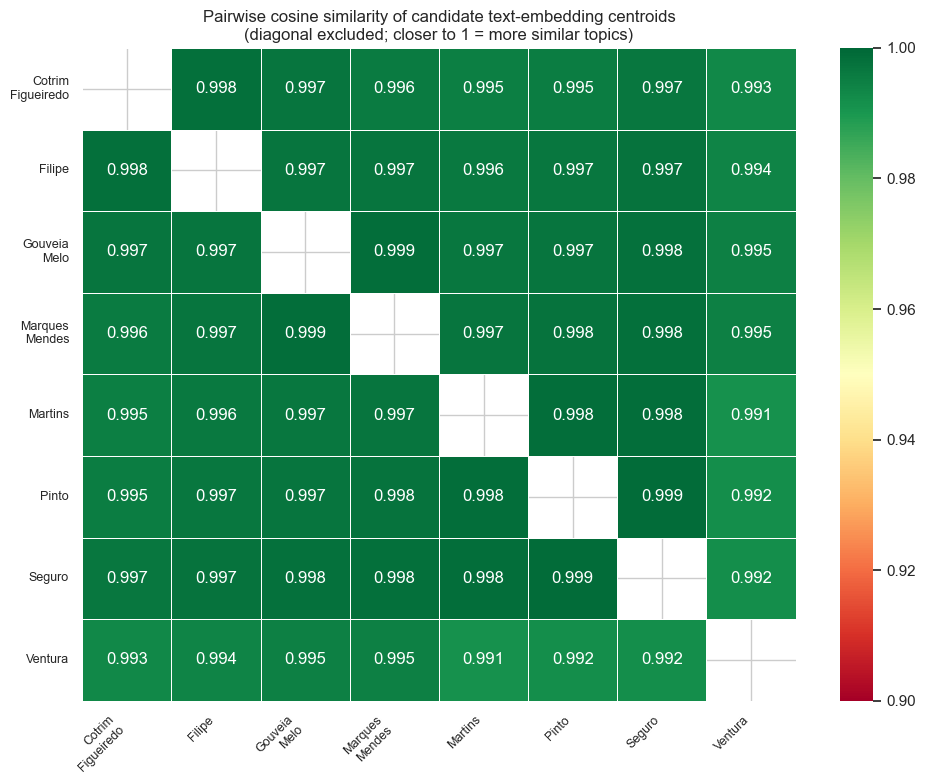

In [14]:
# Candidate centroids in original 4096-d space (NOT PCA-reduced)
centroids_text = {}
for c in CANDIDATES:
    segs = speech_cands[speech_cands['speaker'] == c]['text_embedding']
    if len(segs) > 0:
        centroids_text[c] = np.mean(np.stack(segs.values), axis=0)

cands_present = [c for c in CANDIDATES if c in centroids_text]

# Cosine similarity matrix
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

n = len(cands_present)
sim_matrix = np.zeros((n, n))
for i, ci in enumerate(cands_present):
    for j, cj in enumerate(cands_present):
        sim_matrix[i, j] = cosine_sim(centroids_text[ci], centroids_text[cj])

sim_df = pd.DataFrame(sim_matrix, index=cands_present, columns=cands_present)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask_diag = np.eye(n, dtype=bool)
sns.heatmap(sim_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.9, vmax=1.0,
            ax=ax, mask=mask_diag, linewidths=0.5)
ax.set_title('Pairwise cosine similarity of candidate text-embedding centroids\n'
             '(diagonal excluded; closer to 1 = more similar topics)')
short = {c: c.replace('_', '\n') for c in cands_present}
ax.set_xticklabels([short[c] for c in cands_present], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([short[c] for c in cands_present], rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

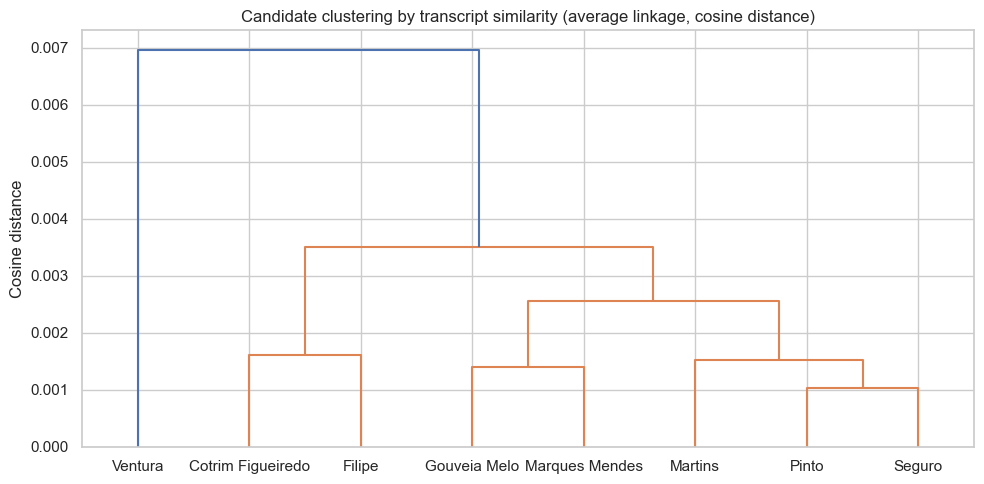

Most similar pairs:
  Pinto — Seguro: 0.9990
  Gouveia_Melo — Marques_Mendes: 0.9986
  Martins — Seguro: 0.9985
Least similar pairs:
  Pinto — Ventura: 0.9919
  Seguro — Ventura: 0.9918
  Martins — Ventura: 0.9912


In [15]:
# Hierarchical clustering dendrogram — which candidates are semantically closest?
dist_matrix = 1.0 - sim_matrix  # cosine distance
np.fill_diagonal(dist_matrix, 0)
# Convert to condensed form for scipy linkage
from scipy.spatial.distance import squareform
Z = linkage(squareform(dist_matrix), method='average')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=[c.replace('_', ' ') for c in cands_present],
           ax=ax, color_threshold=0.6*max(Z[:,2]),
           leaf_font_size=11)
ax.set_title('Candidate clustering by transcript similarity (average linkage, cosine distance)')
ax.set_ylabel('Cosine distance')
plt.tight_layout()
plt.show()

# Print most and least similar pairs (excluding diagonal)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((cands_present[i], cands_present[j], sim_matrix[i,j]))
pairs.sort(key=lambda x: x[2], reverse=True)
print('Most similar pairs:')
for a,b,s in pairs[:3]: print(f'  {a} — {b}: {s:.4f}')
print('Least similar pairs:')
for a,b,s in pairs[-3:]: print(f'  {a} — {b}: {s:.4f}')

---
## Option C — Message discipline (intra-candidate semantic consistency)

**Idea:** a candidate with low within-candidate variance in text-embedding space
talks about the same things in every debate — high message discipline.
A candidate with high variance shifts topics debate to debate.

Metric: mean pairwise cosine similarity among all of a candidate's speech segments.
Higher = more consistent. We then correlate this with mean poll standing.

        candidate  n_segs  mean_cosine_sim  semantic_variance
          Ventura     104         0.960855           0.039145
            Pinto     116         0.960108           0.039892
   Marques_Mendes     119         0.954458           0.045542
           Seguro     101         0.953512           0.046488
          Martins     106         0.950946           0.049054
Cotrim_Figueiredo      98         0.950338           0.049662
     Gouveia_Melo      27         0.945754           0.054246
           Filipe     102         0.944656           0.055344


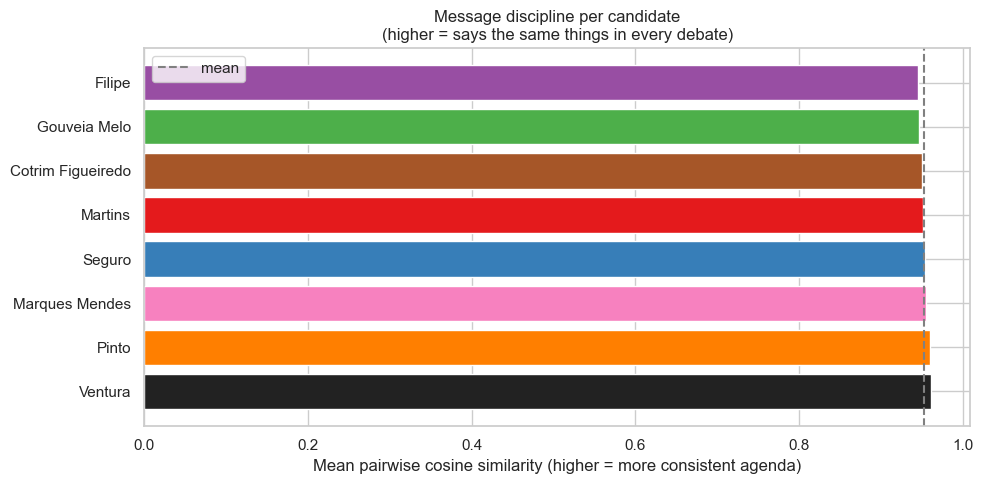

In [16]:
disc_rows = []
for c in CANDIDATES:
    segs = np.stack(speech_cands[speech_cands['speaker'] == c]['text_embedding'].values)
    if len(segs) < 2:
        continue
    # Normalize to unit sphere
    segs_norm = segs / (np.linalg.norm(segs, axis=1, keepdims=True) + 1e-12)
    # Mean pairwise cosine similarity = (sum of all dot products - n) / (n*(n-1))
    gram = segs_norm @ segs_norm.T
    n = len(segs)
    mean_sim = (gram.sum() - n) / (n * (n - 1))
    disc_rows.append({'candidate': c, 'n_segs': n,
                      'mean_cosine_sim': mean_sim,
                      'semantic_variance': 1 - mean_sim})

disc = pd.DataFrame(disc_rows).sort_values('mean_cosine_sim', ascending=False)
print(disc.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = [CAND_COLOR.get(c, '#888') for c in disc['candidate']]
ax.barh(disc['candidate'].str.replace('_', ' '), disc['mean_cosine_sim'], color=colors)
ax.set_xlabel('Mean pairwise cosine similarity (higher = more consistent agenda)')
ax.set_title('Message discipline per candidate\n(higher = says the same things in every debate)')
ax.axvline(disc['mean_cosine_sim'].mean(), ls='--', color='grey', label='mean')
ax.legend()
plt.tight_layout()
plt.show()

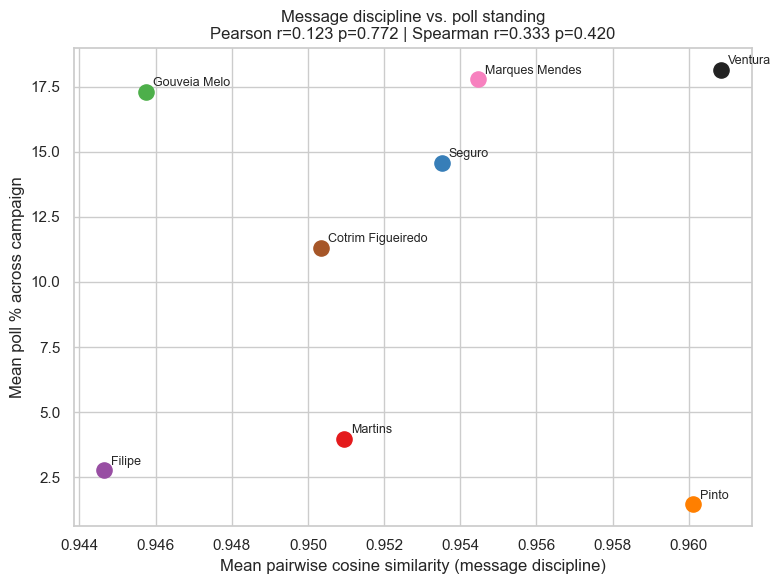

In [17]:
# Correlate message discipline with poll standing
polls = pd.read_pickle(os.path.join(FEATURES_DIR, 'polls_timeline.pkl'))

# Mean poll % per candidate across all polls (proxy for overall campaign standing)
poll_mean = {c: polls[c].mean() for c in CANDIDATES if c in polls.columns}

disc['mean_poll_pct'] = disc['candidate'].map(poll_mean)
disc_valid = disc.dropna(subset=['mean_poll_pct'])

r_p, p_p = pearsonr(disc_valid['mean_cosine_sim'], disc_valid['mean_poll_pct'])
r_s, p_s = spearmanr(disc_valid['mean_cosine_sim'], disc_valid['mean_poll_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in disc_valid.iterrows():
    c = row['candidate']
    ax.scatter(row['mean_cosine_sim'], row['mean_poll_pct'],
               color=CAND_COLOR.get(c, '#888'), s=120, zorder=3)
    ax.annotate(c.replace('_', ' '), (row['mean_cosine_sim'], row['mean_poll_pct']),
                fontsize=9, xytext=(5, 4), textcoords='offset points')
ax.set_xlabel('Mean pairwise cosine similarity (message discipline)')
ax.set_ylabel('Mean poll % across campaign')
ax.set_title(f'Message discipline vs. poll standing\nPearson r={r_p:.3f} p={p_p:.3f} | '
             f'Spearman r={r_s:.3f} p={p_s:.3f}')
plt.tight_layout()
plt.show()

---
## Option D — Semantic drift: does a candidate's agenda shift over the campaign?

For each candidate, compute their mean text-embedding per debate (7 points each),
ordered by debate date. Reduce all 56 points (8 candidates × 7 debates) to 2D via PCA
and plot trajectories with arrows showing time direction.

A candidate whose trajectory is a tight cluster stayed on-message.
A candidate whose trajectory moves in a consistent direction shifted their agenda
as the election approached.

In [18]:
# Parse debate date from video filename
MONTHS = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
          'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}

def parse_date(video_name):
    m = re.search(r'(January|February|March|April|May|June|July|August|'
                  r'September|October|November|December)_(\d+)', video_name)
    if not m: return None
    mon = MONTHS[m.group(1)]
    day = int(m.group(2))
    yr = 2025 if mon >= 10 else 2026
    return date(yr, mon, day)

# Per-candidate × per-debate mean text embedding
drift_rows = []
for v in debate_videos:
    d = parse_date(v)
    if d is None: continue
    cA, cB = extract_candidates(v)
    for c in (cA, cB):
        if c is None: continue
        segs = speech_cands[(speech_cands['video'] == v) & (speech_cands['speaker'] == c)]
        if len(segs) == 0: continue
        centroid = np.mean(np.stack(segs['text_embedding'].values), axis=0)
        drift_rows.append({'candidate': c, 'video': v, 'date': d, 'centroid': centroid})

drift_df = pd.DataFrame(drift_rows).sort_values(['candidate', 'date']).reset_index(drop=True)
print(f'{len(drift_df)} candidate-debate centroids built')
print(drift_df.groupby('candidate').size())

56 candidate-debate centroids built
candidate
Cotrim_Figueiredo    7
Filipe               7
Gouveia_Melo         7
Marques_Mendes       7
Martins              7
Pinto                7
Seguro               7
Ventura              7
dtype: int64


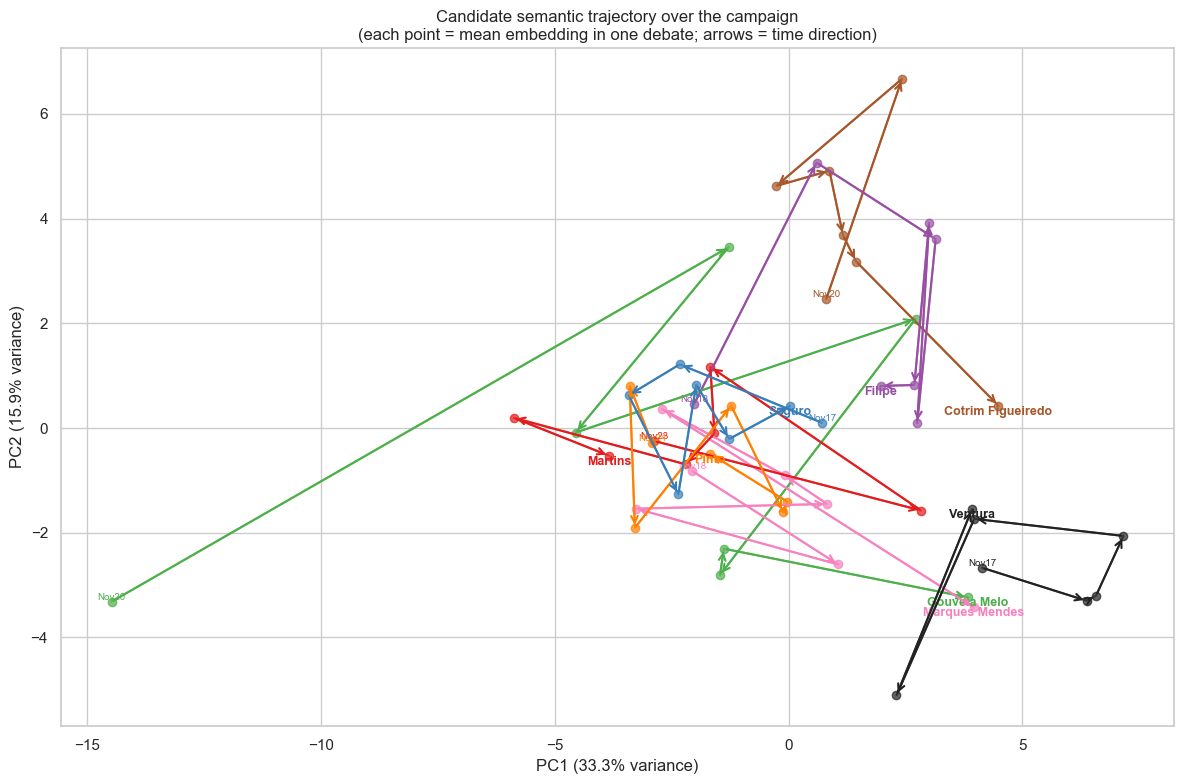

In [19]:
# PCA to 2D on all per-candidate-per-debate centroids
C_matrix = np.stack(drift_df['centroid'].values)
pca2 = PCA(n_components=2, random_state=42)
C_2d = pca2.fit_transform(C_matrix)
drift_df['pc1'] = C_2d[:, 0]
drift_df['pc2'] = C_2d[:, 1]
var1, var2 = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(12, 8))
for c in CANDIDATES:
    sub = drift_df[drift_df['candidate'] == c].sort_values('date')
    if len(sub) < 2: continue
    color = CAND_COLOR.get(c, '#888')
    ax.plot(sub['pc1'], sub['pc2'], '-o', color=color, lw=1.5, alpha=0.7)
    # Arrows showing time direction
    for k in range(len(sub) - 1):
        ax.annotate('', xy=(sub['pc1'].iloc[k+1], sub['pc2'].iloc[k+1]),
                    xytext=(sub['pc1'].iloc[k], sub['pc2'].iloc[k]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    # Label first and last point with date
    ax.text(sub['pc1'].iloc[0],  sub['pc2'].iloc[0],  sub['date'].iloc[0].strftime('%b%d'),
            fontsize=7, color=color, ha='center', va='bottom')
    ax.text(sub['pc1'].iloc[-1], sub['pc2'].iloc[-1], c.replace('_', ' '),
            fontsize=9, color=color, fontweight='bold', ha='center', va='top')

ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('Candidate semantic trajectory over the campaign\n'
             '(each point = mean embedding in one debate; arrows = time direction)')
plt.tight_layout()
plt.show()

Semantic drift (sum of cosine distances between consecutive debates):
        candidate  total_drift  mean_step  n_debates
     Gouveia_Melo     0.124664   0.020777          7
          Martins     0.037043   0.006174          7
   Marques_Mendes     0.032204   0.005367          7
           Filipe     0.028568   0.004761          7
Cotrim_Figueiredo     0.027541   0.004590          7
          Ventura     0.025158   0.004193          7
           Seguro     0.020371   0.003395          7
            Pinto     0.019588   0.003265          7


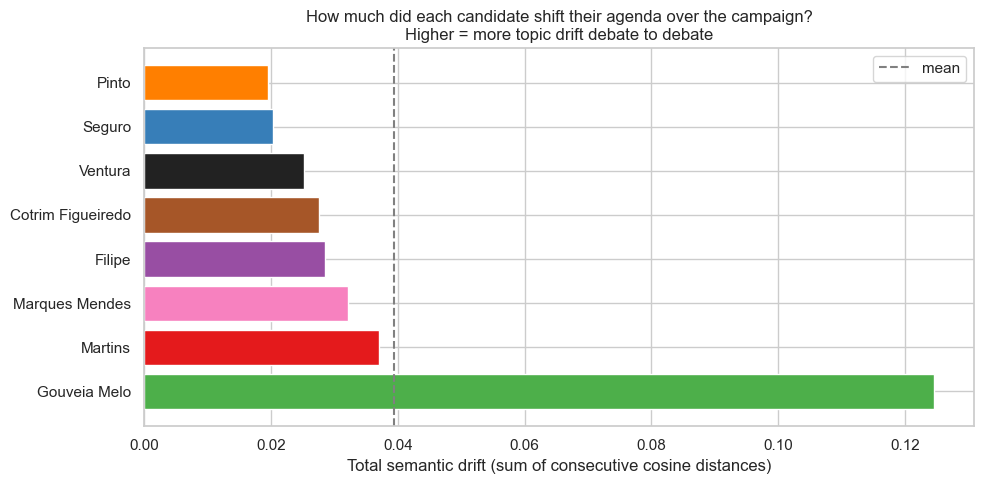

In [20]:
# Quantify total semantic displacement per candidate:
# sum of step-by-step cosine distances between consecutive debates
displacement_rows = []
for c in CANDIDATES:
    sub = drift_df[drift_df['candidate'] == c].sort_values('date')
    if len(sub) < 2: continue
    vecs = np.stack(sub['centroid'].values)
    vecs_norm = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    step_dists = [1 - np.dot(vecs_norm[i], vecs_norm[i+1]) for i in range(len(vecs)-1)]
    displacement_rows.append({'candidate': c,
                               'total_drift': sum(step_dists),
                               'mean_step': np.mean(step_dists),
                               'n_debates': len(sub)})

disp = pd.DataFrame(displacement_rows).sort_values('total_drift', ascending=False)
print('Semantic drift (sum of cosine distances between consecutive debates):')
print(disp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CAND_COLOR.get(c, '#888') for c in disp['candidate']]
ax.barh(disp['candidate'].str.replace('_', ' '), disp['total_drift'], color=colors)
ax.set_xlabel('Total semantic drift (sum of consecutive cosine distances)')
ax.set_title('How much did each candidate shift their agenda over the campaign?\n'
             'Higher = more topic drift debate to debate')
ax.axvline(disp['total_drift'].mean(), ls='--', color='grey', label='mean')
ax.legend()
plt.tight_layout()
plt.show()